In [1]:
import os
os.chdir("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [2]:
MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(kernel="rbf", class_weight="balanced"),  # probability=True removed — much faster
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}
FEATURE_COLS = ["hr", "hrv", "eda", "wrist_temp", "spo2", "co2_noisy", "lux_noisy", "posture_cm"]

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report

MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(kernel="rbf", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}
FEATURE_COLS = ["hr", "hrv", "eda", "wrist_temp", "co2_noisy", "lux_noisy", "posture_cm"]

df = pd.read_csv("outputs/unified_features.csv").dropna(subset=FEATURE_COLS)
X = df[FEATURE_COLS].values
le = LabelEncoder()
y = le.fit_transform(df["ground_truth"])
groups = df["subject"].values

N_REPEATS = 10  # 10 repeats x 5 folds = 50 scores per model, enough power for real significance testing
scaler = StandardScaler()
per_fold_f1 = {name: [] for name in MODELS}
per_fold_f1["RuleEngine"] = []
all_preds = {name: [] for name in MODELS}
all_true = []

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=repeat)
    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        X_train = scaler.fit_transform(X[train_idx])
        X_test = scaler.transform(X[test_idx])
        y_train, y_test = y[train_idx], y[test_idx]
        all_true.extend(y_test)

        rule_preds = le.transform(df["rule_prediction_binary"].values[test_idx])
        per_fold_f1["RuleEngine"].append(f1_score(y_test, rule_preds, average="macro", zero_division=0))

        for name, model in MODELS.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            all_preds[name].extend(preds)
            per_fold_f1[name].append(f1_score(y_test, preds, average="macro", zero_division=0))
    print(f"Repeat {repeat+1}/{N_REPEATS} done")

print(f"\nTotal fold-scores per model: {len(per_fold_f1['RuleEngine'])}")

Repeat 1/10 done
Repeat 2/10 done
Repeat 3/10 done
Repeat 4/10 done
Repeat 5/10 done
Repeat 6/10 done
Repeat 7/10 done
Repeat 8/10 done
Repeat 9/10 done
Repeat 10/10 done

Total fold-scores per model: 50


             Model  Mean_Macro_F1      Std
LogisticRegression       0.743812 0.130790
      RandomForest       0.730598 0.091181
  GradientBoosting       0.723334 0.113563
               MLP       0.683362 0.109444
        RuleEngine       0.667595 0.129009
               SVM       0.652526 0.119232


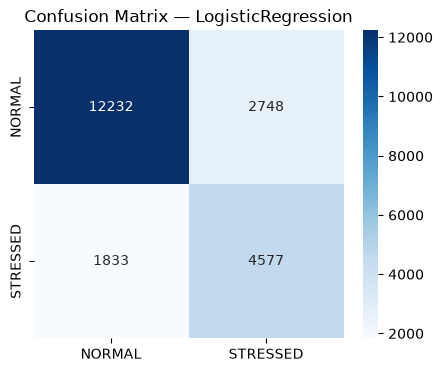

              precision    recall  f1-score   support

      NORMAL       0.87      0.82      0.84     14980
    STRESSED       0.62      0.71      0.67      6410

    accuracy                           0.79     21390
   macro avg       0.75      0.77      0.75     21390
weighted avg       0.80      0.79      0.79     21390



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

summary = pd.DataFrame([
    {"Model": name, "Mean_Macro_F1": np.mean(s), "Std": np.std(s)}
    for name, s in per_fold_f1.items()
]).sort_values("Mean_Macro_F1", ascending=False)
print(summary.to_string(index=False))

summary.to_csv("outputs/model_comparison_results.csv", index=False)
pd.DataFrame(per_fold_f1).to_csv("outputs/per_fold_f1_scores.csv", index=False)

best_model = summary.iloc[0]["Model"]
if best_model == "RuleEngine":
    best_model = summary.iloc[1]["Model"]

cm = confusion_matrix(all_true, all_preds[best_model])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_model}")
plt.savefig("outputs/confusion_matrix_best_model.png", dpi=200)
plt.show()

print(classification_report(all_true, all_preds[best_model], target_names=le.classes_))

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("outputs/unified_features.csv")

# Check every feature individually — does the STRESSED class's range for
# any single feature sit COMPLETELY outside the NORMAL class's range?
# If so, that one feature alone can perfectly separate the classes.
feature_cols = ["hr", "hrv", "eda", "wrist_temp", "spo2", "co2_noisy", "lux_noisy", "posture_cm"]

for col in feature_cols:
    normal_range = (df[df.ground_truth == "NORMAL"][col].min(), df[df.ground_truth == "NORMAL"][col].max())
    stressed_range = (df[df.ground_truth == "STRESSED"][col].min(), df[df.ground_truth == "STRESSED"][col].max())
    overlap = not (stressed_range[1] < normal_range[0] or stressed_range[0] > normal_range[1])
    print(f"{col:15s} NORMAL: {normal_range}  STRESSED: {stressed_range}  Overlap: {overlap}")

hr              NORMAL: (np.float64(48.0), np.float64(106.0))  STRESSED: (np.float64(64.0), np.float64(148.0))  Overlap: True
hrv             NORMAL: (np.float64(4.838322410247003), np.float64(218.9098298511105))  STRESSED: (np.float64(2.041241452319318), np.float64(216.70639540073608))  Overlap: True
eda             NORMAL: (np.float64(0.5724526904878162), np.float64(13.002052161807104))  STRESSED: (np.float64(1.1796703520275298), np.float64(20.15147370837984))  Overlap: True
wrist_temp      NORMAL: (np.float64(28.17887), np.float64(35.093987))  STRESSED: (np.float64(31.061766), np.float64(35.63516))  Overlap: True


KeyError: 'spo2'

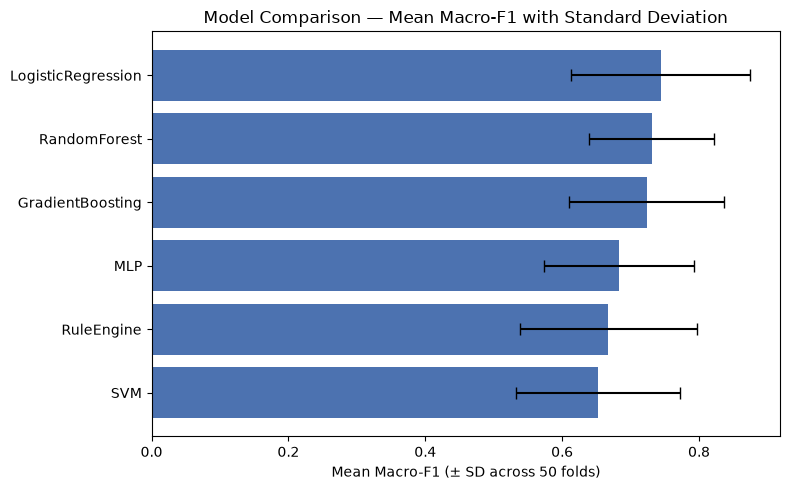

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv("outputs/model_comparison_results.csv").sort_values("Mean_Macro_F1", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(summary["Model"], summary["Mean_Macro_F1"], xerr=summary["Std"], capsize=4, color="#4C72B0")
plt.xlabel("Mean Macro-F1 (± SD across 50 folds)")
plt.title("Model Comparison — Mean Macro-F1 with Standard Deviation")
plt.tight_layout()
plt.savefig("outputs/figure4_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()